In [8]:
# ==========================================
# IMPORTS
# ==========================================

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (300,300)
BATCH_SIZE = 32
NUM_CLASSES = 7

In [9]:

print("TensorFlow Version :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"GPU Detected : {gpus[0].name}")
else:
    print("Running on CPU")

TensorFlow Version : 2.19.0
GPU Detected : /physical_device:GPU:0


In [10]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random Seed Set :", SEED)

IMG_SIZE = (300, 300)

BATCH_SIZE = 32

NUM_CLASSES = 7

EPOCHS_STAGE1 = 15

EPOCHS_STAGE2 = 20

AUTOTUNE = tf.data.AUTOTUNE

Random Seed Set : 42


In [11]:

DATASET_ROOT = "/kaggle/input/datasets/adithashok/odir10k"

TRAIN_DIR = os.path.join(DATASET_ROOT,"train")
VAL_DIR = os.path.join(DATASET_ROOT,"val")
TEST_DIR = os.path.join(DATASET_ROOT,"test")

print(TRAIN_DIR)
print(VAL_DIR)
print(TEST_DIR)

/kaggle/input/datasets/adithashok/odir10k/train
/kaggle/input/datasets/adithashok/odir10k/val
/kaggle/input/datasets/adithashok/odir10k/test


In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 8489 files belonging to 7 classes.


I0000 00:00:1782394040.684426      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782394040.690235      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1818 files belonging to 7 classes.
Found 1824 files belonging to 7 classes.


In [13]:
print(train_ds.class_names)

['ageDegeneration', 'cataract', 'diabetes', 'glaucoma', 'hypertension', 'myopia', 'normal']


In [14]:
train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

In [15]:
images, labels = next(iter(train_ds))
print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 300, 300, 3)
Label Batch Shape : (32, 7)


In [16]:
# Class names
class_names = [
    "ageDegeneration",
    "cataract",
    "diabetes",
    "glaucoma",
    "hypertension",
    "myopia",
    "normal"
]

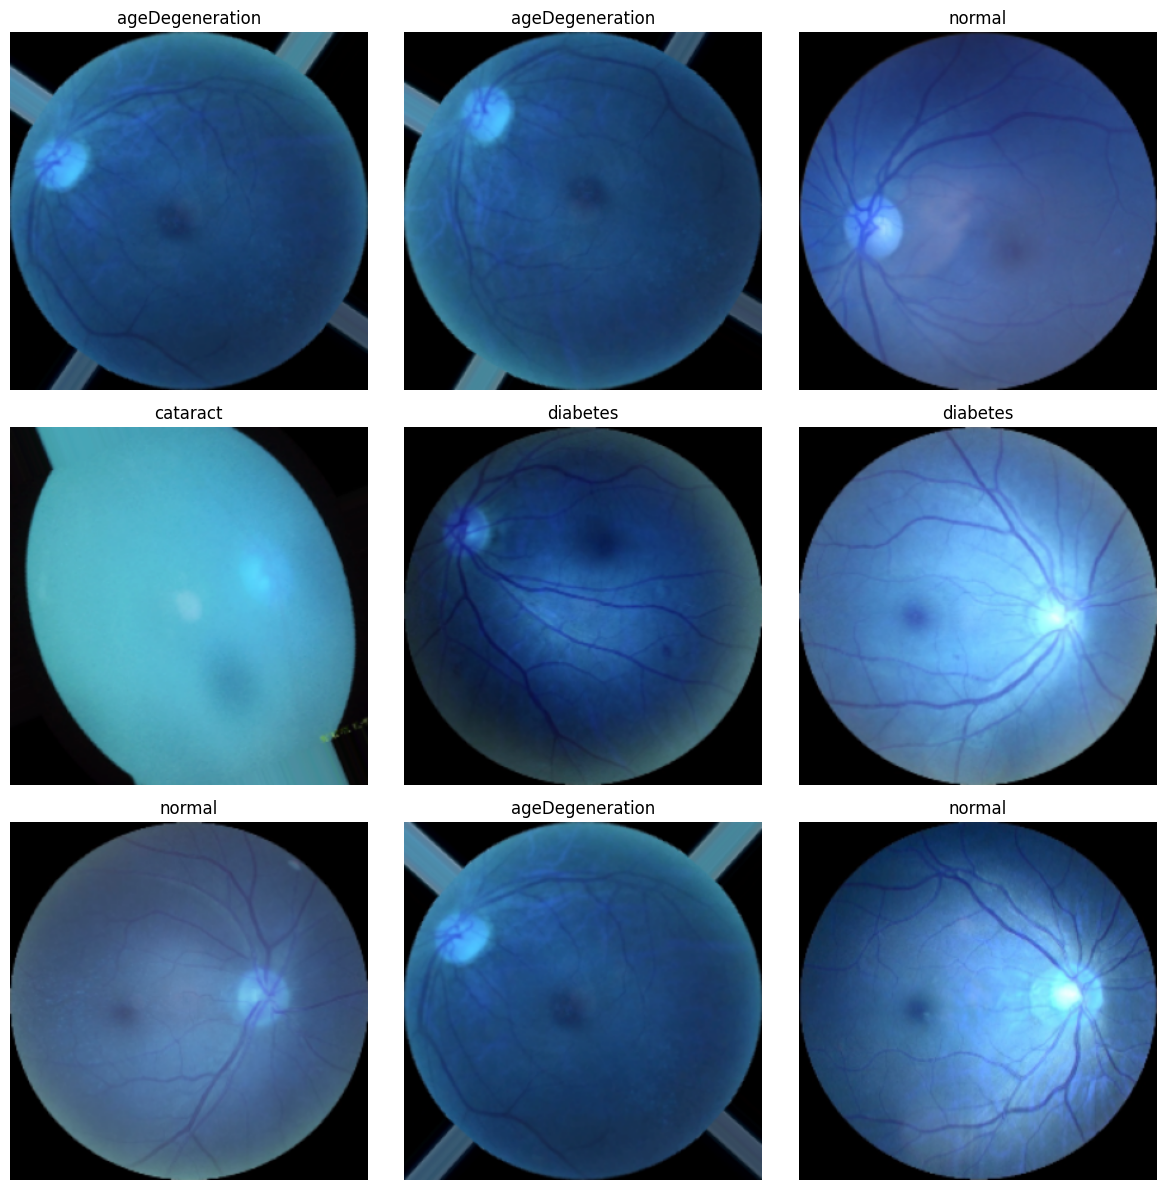

In [17]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("Dataset Pipeline Ready!")

Dataset Pipeline Ready!


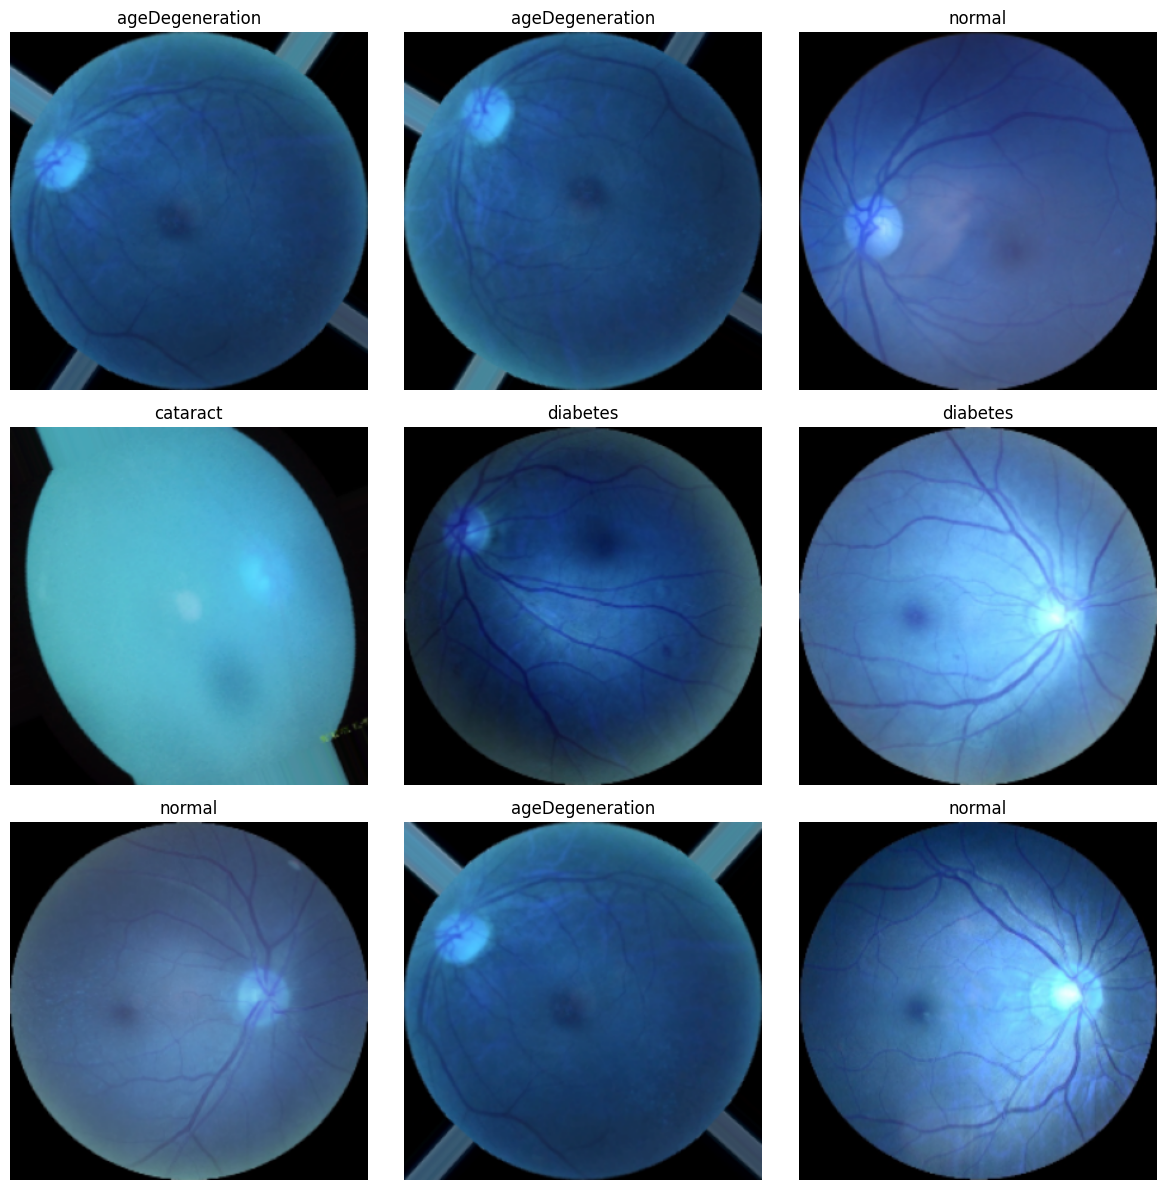

In [19]:
plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i].numpy().astype("uint8"))

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [20]:
from tensorflow import keras
from tensorflow.keras import layers
data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.08),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.10),

], name="augmentation")

In [21]:
# ==========================================
# SECTION 5 : MODEL
# ==========================================

import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2S
base_model = EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(300, 300, 3)
)

# Freeze the backbone for Stage 1
base_model.trainable = False

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
inputs = tf.keras.Input(shape=(300, 300, 3))

# Data Augmentation
x = data_augmentation(inputs)

# EfficientNetV2 preprocessing
x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

# Feature extraction
x = base_model(x, training=False)

# Classification Head
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32"
)(x)

model = Model(inputs, outputs)

In [23]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 10, 10, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,667,239 (78.84 MB)

 Trainable params: 332,807 (1.27 MB)

 Non-trainable params: 20,334,432 (77.57 MB)

In [24]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [25]:
callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

In [26]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get labels from train_ds
y_train = []

for _, labels in train_ds.unbatch():
    y_train.append(np.argmax(labels.numpy()))

y_train = np.array(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(1.195970695970696), 1: np.float64(1.1549659863945578), 2: np.float64(1.077968253968254), 3: np.float64(0.9624716553287982), 4: np.float64(1.1549659863945578), 5: np.float64(1.2387275645702611), 6: np.float64(0.6030404205441501)}


In [ ]:
model = tf.keras.models.load_model("best_model.keras")

test_loss, test_acc, test_precision, test_recall = model.evaluate(test_ds)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False
    learning_rate = 1e-5
epochs = 10

In [ ]:
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(
    gamma=2.0
)
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-5   # Lower LR for fine-tuning
)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
base_model.trainable = True

# Freeze the lower layers, train only the top layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load best model
model = tf.keras.models.load_model("best_model.keras")

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.save("baseline_84_8.keras")

In [28]:
!pip install -q keras-tuner
import keras_tuner as kt
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras import layers
import tensorflow as tf

In [29]:
def build_model(hp):

    base_model = EfficientNetV2S(
        include_top=False,
        weights="imagenet",
        input_shape=(300,300,3)
    )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=(300,300,3))

    x = data_augmentation(inputs)

    x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    dropout = hp.Float(
        "dropout",
        min_value=0.2,
        max_value=0.5,
        step=0.1
    )

    x = layers.Dropout(dropout)(x)

    units = hp.Choice(
        "dense_units",
        values=[128,256,512]
    )

    x = layers.Dense(
        units,
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        7,
        activation="softmax"
    )(x)

    model = tf.keras.Model(inputs, outputs)

    lr = hp.Choice(
        "learning_rate",
        values=[1e-3,5e-4,1e-4]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [31]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=8,
    directory="tuner_results",
    project_name="ODIR10K"
)

In [48]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

base_model = model.get_layer("efficientnetv2-s")
last_conv_layer = "top_conv"

# Build a model from the EfficientNet input
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        base_model.get_layer(last_conv_layer).output,
        base_model.output
    ]
)

True Label: ageDegeneration


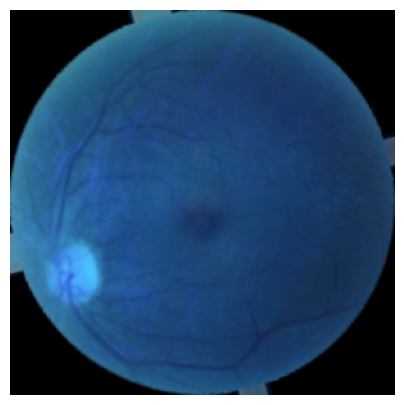

In [50]:
# Get one batch from the test dataset
images, labels = next(iter(test_ds))

# Select the first image
img_array = images[0].numpy()

# True label
true_label = np.argmax(labels[0].numpy())

print("True Label:", class_names[true_label])

plt.figure(figsize=(5,5))
plt.imshow(img_array.astype("uint8"))
plt.axis("off")
plt.show()

In [47]:
base_model = model.get_layer("efficientnetv2-s")

for layer in reversed(base_model.layers):
    if "conv" in layer.name.lower():
        print(layer.name, layer.output.shape)
        break

top_conv (None, 10, 10, 1280)


In [51]:
img = tf.expand_dims(img_array, axis=0)

# Pass through augmentation if your model has it
augmented = model.get_layer("augmentation")(img, training=False)

with tf.GradientTape() as tape:

    conv_outputs, features = grad_model(augmented)

    x = model.get_layer("global_average_pooling2d")(features)
    x = model.get_layer("batch_normalization")(x, training=False)
    x = model.get_layer("dropout")(x, training=False)
    x = model.get_layer("dense")(x)
    x = model.get_layer("batch_normalization_1")(x, training=False)
    x = model.get_layer("dropout_1")(x, training=False)

    preds = model.get_layer("dense_1")(x)

    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

heatmap = tf.maximum(heatmap,0)
heatmap /= tf.reduce_max(heatmap)

heatmap = heatmap.numpy()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.5 MB/s eta 0:00:00


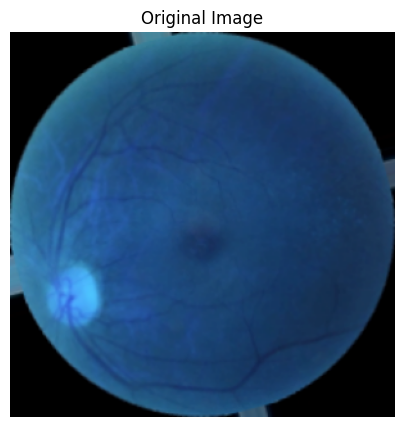

True Class : ageDegeneration


In [52]:
!pip install -q tf-keras-vis
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
model = tf.keras.models.load_model("best_model.keras")
images, labels = next(iter(test_ds))

image = images[0].numpy()
true_class = np.argmax(labels[0])

plt.figure(figsize=(5,5))
plt.imshow(image.astype("uint8"))
plt.title("Original Image")
plt.axis("off")
plt.show()

print("True Class :", class_names[true_class])

In [54]:
gradcam = Gradcam(
    model,
    model_modifier=ReplaceToLinear(),
    clone=True
)
score = CategoricalScore(true_class)

cam = gradcam(
    score,
    image[np.newaxis, ...],
    penultimate_layer="top_conv"
)

cam = cam[0]
plt.figure(figsize=(6,6))
plt.imshow(cam, cmap="jet")
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()
import cv2

heatmap = cv2.resize(cam, (300,300))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    image.astype("uint8"),
    0.6,
    heatmap,
    0.4,
    0
)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM Overlay")
plt.show()

KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m138532106010592\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=['tf.Tensor(shape=(1, 300, 300, 3), dtype=float32)']\n  • training=False\n  • mask=['None']\n  • kwargs=<class 'inspect._empty'>"